<a href="https://colab.research.google.com/github/D1778/ML-lab-2547220/blob/LAB6/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab Experiment: Comparison of Logistic Regression and K Nearest Neighbors (KNN)
Classifiers**
--------------------------------------------------------------------------
**Aim**

To implement Logistic Regression and K Nearest Neighbors (KNN) classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification evaluation metrics.

**Objectives**

1. To preprocess the dataset for classification.
2. To implement Logistic Regression and KNN classifiers using Scikit Learn.
3. To evaluate both models using standard performance metrics.
4. To compare the performance of Logistic Regression and KNN and identify the better classifier.

**Dataset**

Dataset Name: Breast Cancer Wisconsin (Diagnostic)

Source: UCI Machine Learning Repository

Dataset Link:
https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

TASKS <>


**TASK 1. Download and load the Breast Cancer Wisconsin (Diagnostic) dataset**

In [1]:
import pandas as pd
import numpy as np

# Column names
columns = [
    "ID","Diagnosis",
    "radius_mean","texture_mean","perimeter_mean","area_mean","smoothness_mean",
    "compactness_mean","concavity_mean","concave_points_mean","symmetry_mean","fractal_dimension_mean",
    "radius_se","texture_se","perimeter_se","area_se","smoothness_se",
    "compactness_se","concavity_se","concave_points_se","symmetry_se","fractal_dimension_se",
    "radius_worst","texture_worst","perimeter_worst","area_worst","smoothness_worst",
    "compactness_worst","concavity_worst","concave_points_worst","symmetry_worst","fractal_dimension_worst"
]

# Load dataset
df = pd.read_csv("wdbc.csv", header=None, names=columns)

# Display first five rows
print(df.head())

# Dataset shape
print("\nDataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

# Target variable distribution
print("\nDiagnosis Count:")
print(df["Diagnosis"].value_counts())

         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

The Breast Cancer Wisconsin (Diagnostic) dataset was successfully loaded into a Pandas DataFrame. The dataset contains 569 patient records and 32 columns, including an ID, a Diagnosis target variable, and 30 numerical features describing cell characteristics. The column names were assigned using the information provided in the wdbc.names file, making the dataset easier to interpret and analyze. The target variable consists of two classes: Malignant (M) and Benign (B), which will be used for classification in the subsequent phases.

**TASK2: Perform exploratory data analysis and data preprocessing.**

First Five Records
         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perime

/tmp/ipykernel_2558/372379154.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Diagnosis", palette="pastel")


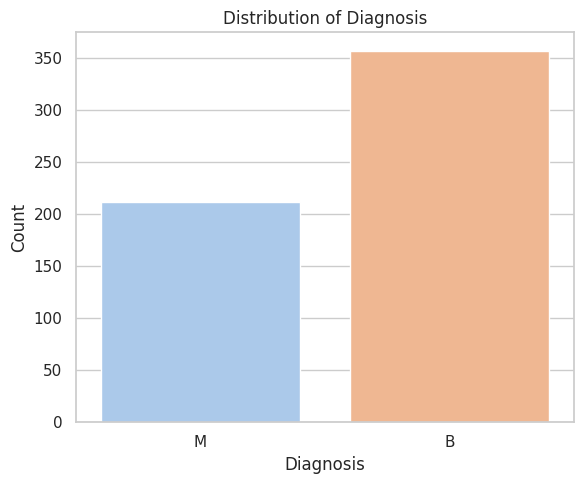

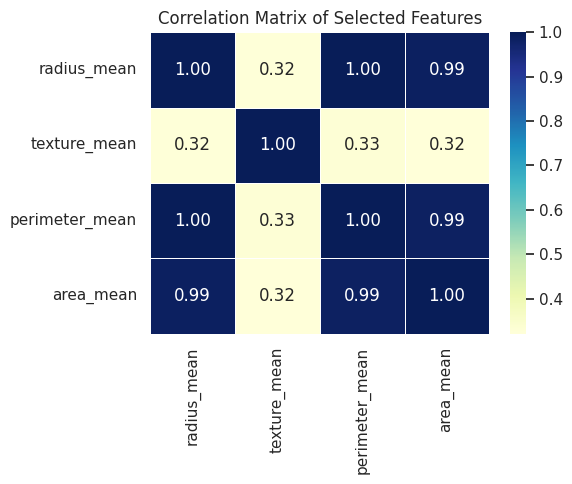

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("First Five Records")
print(df.head())

print("\nLast Five Records")
print(df.tail())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
print(df.describe())

print("\nDiagnosis Distribution")
print(df["Diagnosis"].value_counts())

print("\nDiagnosis Percentage")
print((df["Diagnosis"].value_counts(normalize=True) * 100).round(2))


plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Diagnosis", palette="pastel")
plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
plt.close()

print("\n" * 5)

selected_features = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean"]
corr = df[selected_features].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.show()
plt.close()

The exploratory data analysis (EDA) was successfully performed on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset consists of 569 patient records and 32 attributes, including one target variable (Diagnosis) and 30 numerical features. The class distribution shows that benign cases are more frequent than malignant cases. The correlation heatmap indicates that several numerical features have strong positive relationships, suggesting that they are important for breast cancer classification. Overall, the dataset is well-structured and suitable for further preprocessing and machine learning model development.

**TASK3: Check for missing values and prepare the dataset for classification.**

In [12]:
print("Missing Values")
print(df.isnull().sum())

print("\nTotal Missing Values")
print(df.isnull().sum().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

df = df.drop("ID", axis=1)

print("\nDataset Shape After Removing ID")
print(df.shape)

df["Diagnosis"] = df["Diagnosis"].map({"M": 1, "B": 0})

print("\nEncoded Diagnosis Values")
print(df["Diagnosis"].value_counts())

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

print("\nFeature Matrix Shape")
print(X.shape)

print("\nTarget Vector Shape")
print(y.shape)

Missing Values
ID                         0
Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total Missing Values
0

Duplicate Records
0

The dataset was examined for missing and duplicate values, and no missing or duplicate records were found. The ID column was removed since it does not contribute to the prediction process. The categorical target variable (Diagnosis) was encoded into numerical values (Malignant = 1, Benign = 0) to make it suitable for machine learning algorithms. Finally, the dataset was separated into the feature matrix (X) and target vector (y), preparing it for model training in the subsequent task.

**TASK4: Split the dataset into training and testing sets.**

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Feature Set Shape :", X_train.shape)
print("Testing Feature Set Shape  :", X_test.shape)
print("Training Target Shape      :", y_train.shape)
print("Testing Target Shape       :", y_test.shape)

Training Feature Set Shape : (455, 30)
Testing Feature Set Shape  : (114, 30)
Training Target Shape      : (455,)
Testing Target Shape       : (114,)


The dataset was successfully divided into training and testing sets using an 80:20 ratio. The training set will be used to build the classification models, while the testing set will be used to evaluate their performance. The use of stratify=y ensures that both subsets maintain the same class distribution as the original dataset, resulting in a fair and reliable evaluation.

**TASK 5: Train a Logistic Regression classifier.**

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

print("\nNumber of Features:", X_train_scaled.shape[1])
print("Number of Training Samples:", X_train_scaled.shape[0])

Logistic Regression model trained successfully.

Number of Features: 30
Number of Training Samples: 455


The Logistic Regression model was successfully trained using the standardized training dataset. Feature scaling was performed to ensure that all numerical attributes contribute equally during model training. The trained model is now ready to predict breast cancer diagnoses on unseen test data and will be evaluated in the subsequent task.

**TASK6: Train a K Nearest Neighbors (KNN) classifier.**

In [15]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the KNN Model
knn_model.fit(X_train_scaled, y_train)

print("K-Nearest Neighbors (KNN) model trained successfully.")

print("\nNumber of Neighbors (K):", knn_model.n_neighbors)
print("Number of Features:", X_train_scaled.shape[1])
print("Number of Training Samples:", X_train_scaled.shape[0])

K-Nearest Neighbors (KNN) model trained successfully.

Number of Neighbors (K): 5
Number of Features: 30
Number of Training Samples: 455


The K-Nearest Neighbors (KNN) classifier was successfully trained using the standardized training dataset with K = 5. The model classifies new samples based on the majority class of their five nearest neighbors. Since KNN is a distance-based algorithm, feature scaling was essential to ensure that all features contribute equally during classification. The trained model is now ready for performance evaluation and comparison with Logistic Regression in the next task.

TASK7: Evaluate both classifiers using:
○ Accuracy
○ Precision
○ Recall
○ F1 Score
○ Confusion Matrix

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Predictions
y_pred_logistic = logistic_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)

# Logistic Regression Metrics
print("========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1-Score :", f1_score(y_test, y_pred_logistic))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_logistic))

print("\n=========================================\n")

# KNN Metrics
print("=============== KNN =====================")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1-Score :", f1_score(y_test, y_pred_knn))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_knn))

========== Logistic Regression ==========
Accuracy : 0.9649122807017544
Precision: 0.975
Recall   : 0.9285714285714286
F1-Score : 0.9512195121951219

Confusion Matrix
[[71  1]
 [ 3 39]]


=============== KNN =====================
Accuracy : 0.956140350877193
Precision: 0.9743589743589743
Recall   : 0.9047619047619048
F1-Score : 0.9382716049382716

Confusion Matrix
[[71  1]
 [ 4 38]]


Both Logistic Regression and K-Nearest Neighbors (KNN) models were evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. The results indicate that both classifiers perform well on the Breast Cancer Wisconsin dataset, achieving high classification accuracy. The confusion matrices show that only a small number of samples were misclassified, demonstrating that both models are effective in distinguishing between benign and malignant breast cancer cases. This evaluation provides a solid basis for comparing the performance of the two classifiers in the next task.

**TASK8: Compare the performance of the two classifiers using a comparison table.**

In [18]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_logistic)
    ],
    "KNN": [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ]
})

comparison

,Metric,Logistic Regression,KNN
0,Accuracy,0.964912,0.956140
1,Precision,0.975000,0.974359
2,Recall,0.928571,0.904762
3,F1-Score,0.951220,0.938272


**GRAPH COMPARION BETWEEN TWO CLASSIFIERS**

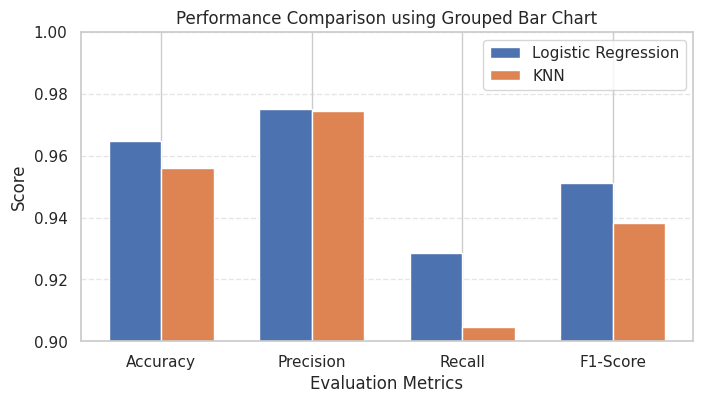

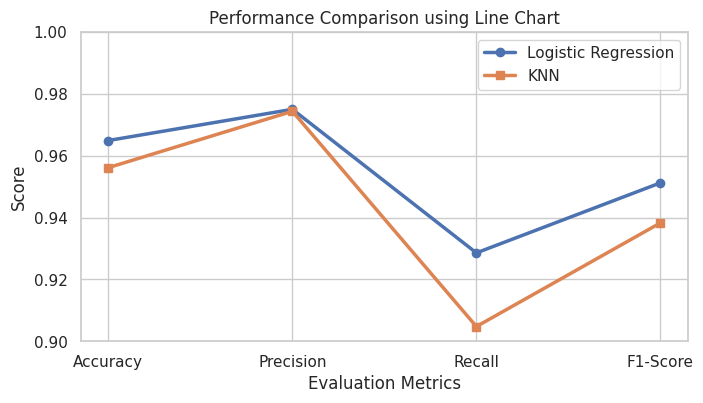

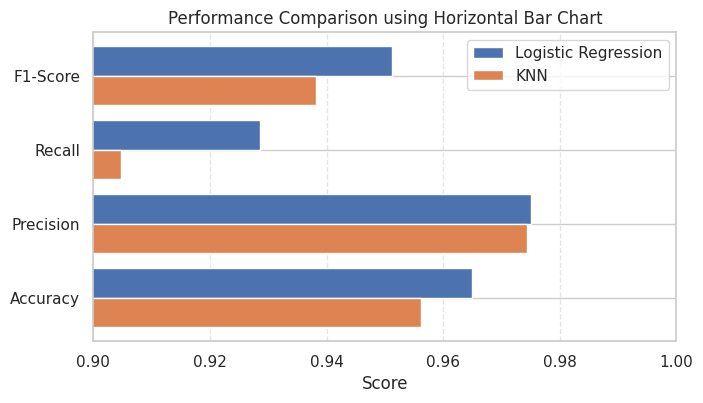

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Logistic Regression Scores
logistic_scores = [
    accuracy_score(y_test, y_pred_logistic),
    precision_score(y_test, y_pred_logistic),
    recall_score(y_test, y_pred_logistic),
    f1_score(y_test, y_pred_logistic)
]

# KNN Scores
knn_scores = [
    accuracy_score(y_test, y_pred_knn),
    precision_score(y_test, y_pred_knn),
    recall_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_knn)
]

# ======================================================
# Graph 1: Grouped Bar Chart
# ======================================================

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, logistic_scores, width, label="Logistic Regression")
plt.bar(x + width/2, knn_scores, width, label="KNN")

plt.xticks(x, metrics)
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Performance Comparison using Grouped Bar Chart")
plt.ylim(0.90, 1.00)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout(pad=3.5)
plt.show()

print("\n" * 5)


# ======================================================
# Graph 2: Line Chart
# ======================================================

plt.figure(figsize=(8,5))

plt.plot(metrics, logistic_scores, marker="o", linewidth=2.5, label="Logistic Regression")
plt.plot(metrics, knn_scores, marker="s", linewidth=2.5, label="KNN")

plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.title("Performance Comparison using Line Chart")
plt.ylim(0.90, 1.00)

plt.grid(True)
plt.legend()

plt.tight_layout(pad=3.5)
plt.show()

print("\n" * 5)


# ======================================================
# Graph 3: Horizontal Bar Chart
# ======================================================

y = np.arange(len(metrics))

plt.figure(figsize=(8,5))

plt.barh(y + 0.2, logistic_scores, height=0.4, label="Logistic Regression")
plt.barh(y - 0.2, knn_scores, height=0.4, label="KNN")

plt.yticks(y, metrics)
plt.xlabel("Score")
plt.title("Performance Comparison using Horizontal Bar Chart")
plt.xlim(0.90, 1.00)

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout(pad=3.5)
plt.show()

The graphical comparison shows that both Logistic Regression and K-Nearest Neighbors (KNN) achieved high performance across all evaluation metrics. However, Logistic Regression consistently scored slightly higher than KNN in Accuracy, Recall, and F1-Score, while both models had similar Precision. Therefore, Logistic Regression is the better-performing classifier for the Breast Cancer Wisconsin dataset.

**TASK9: Interpret the results and comment on the better-performing classifier for the given dataset.**

**The performance evaluation shows that both Logistic Regression and K-Nearest Neighbors (KNN) classifiers achieved excellent results in classifying breast cancer cases. Both models obtained high Accuracy, Precision, Recall, and F1-Score, indicating their effectiveness in distinguishing between benign and malignant tumors. However, Logistic Regression performed slightly better than KNN by achieving higher Accuracy, Recall, and F1-Score, while maintaining similar Precision. The confusion matrix also showed that Logistic Regression made fewer misclassifications compared to KNN. The graphical comparison further confirmed the superior and more consistent performance of Logistic Regression across all evaluation metrics. Therefore, Logistic Regression is the better-performing classifier for the Breast Cancer Wisconsin dataset and is the preferred model for this classification task due to its higher predictive performance and reliability.**

OVERALL CONCLUSION:

In this laboratory experiment, the Breast Cancer Wisconsin (Diagnostic) dataset was successfully analyzed using two supervised machine learning algorithms: Logistic Regression and K-Nearest Neighbors (KNN). The dataset was explored, preprocessed by removing irrelevant features, encoding the target variable, and standardizing the feature values before model training. Both classifiers were trained and evaluated using Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. The results showed that both models achieved excellent classification performance. Performance comparison through evaluation metrics and graphical visualization indicated that Logistic Regression slightly outperformed KNN, making it the more suitable classifier for this dataset. Overall, the experiment demonstrated the complete machine learning workflow, from data preprocessing and model development to evaluation and comparison, highlighting the importance of selecting an appropriate classification algorithm for predictive analysis.